# visualizing distribution function moments

This notebook uses:

- a 2d velocity-space slice for raw moments
- a full 3d pressure tensor when rotational geometry matters
- Legendre and spherical-harmonic-like angular patterns to connect Cartesian tensors to $\ell$ modes

The central object is

$$
M^{(k)}_{i_1\cdots i_k} = \int v_{i_1}\cdots v_{i_k} f(\mathbf{v})\, d^3v,
$$

with special cases

$$
M^{(0)} = \int f\,d^3v,
\qquad
M^{(1)}_i = \int v_i f\,d^3v,
\qquad
M^{(2)}_{ij} = \int v_i v_j f\,d^3v.
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from numpy.polynomial import legendre as npleg

plt.rcParams['figure.dpi'] = 200
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['image.cmap'] = 'viridis'


def gaussian_2d(vx, vy, mean, cov):
    inv_cov = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)
    dx = vx - mean[0]
    dy = vy - mean[1]
    quad = inv_cov[0, 0] * dx**2 + 2 * inv_cov[0, 1] * dx * dy + inv_cov[1, 1] * dy**2
    norm = 1 / (2 * np.pi * np.sqrt(det_cov))
    return norm * np.exp(-0.5 * quad)


def raw_moments_2d(f, vx, vy):
    dvx = float(vx[0, 1] - vx[0, 0])
    dvy = float(vy[1, 0] - vy[0, 0])
    weight = f * dvx * dvy
    m0 = weight.sum()
    m1 = np.array([
        (vx * weight).sum(),
        (vy * weight).sum(),
    ])
    m2 = np.array([
        [(vx * vx * weight).sum(), (vx * vy * weight).sum()],
        [(vy * vx * weight).sum(), (vy * vy * weight).sum()],
    ])
    return {'m0': m0, 'm1': m1, 'm2': m2}


def centered_tensor_2d(moments):
    bulk = moments['m1'] / moments['m0']
    return moments['m2'] / moments['m0'] - np.outer(bulk, bulk)


def rotation_matrix(theta):
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [c, -s],
        [s, c],
    ])


def ellipse_points(tensor, center, level=1.6, npts=300):
    evals, evecs = np.linalg.eigh(tensor)
    evals = np.clip(evals, 0, None)
    angle = np.linspace(0, 2 * np.pi, npts)
    circle = np.vstack([np.cos(angle), np.sin(angle)])
    scaled = evecs @ np.diag(np.sqrt(evals) * level) @ circle
    return center[:, None] + scaled


def pressure_tensor(b, p_parallel, p_perp):
    b = np.asarray(b, dtype=float)
    b = b / np.linalg.norm(b)
    return p_perp * np.eye(3) + (p_parallel - p_perp) * np.outer(b, b)


def ellipsoid_from_tensor(tensor, level=1.0, n_theta=55, n_phi=110):
    evals, evecs = np.linalg.eigh(tensor)
    evals = np.clip(evals, 0, None)
    theta = np.linspace(0, np.pi, n_theta)
    phi = np.linspace(0, 2 * np.pi, n_phi)
    theta, phi = np.meshgrid(theta, phi)
    sphere = np.stack([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta),
    ], axis=0).reshape(3, -1)
    scaled = evecs @ np.diag(np.sqrt(evals) * level) @ sphere
    x = scaled[0].reshape(theta.shape)
    y = scaled[1].reshape(theta.shape)
    z = scaled[2].reshape(theta.shape)
    return x, y, z


def legendre_mode(l, mu):
    coeffs = np.zeros(l + 1)
    coeffs[l] = 1
    return npleg.legval(mu, coeffs)


## 1. raw moments as weighted pictures

Each raw moment multiplies the same distribution by a different polynomial in velocity.

- $M^{(0)}$ weights by $1$
- $M^{(1)}$ weights by one power of velocity
- $M^{(2)}$ weights by two powers of velocity

This shows a shifted anisotropic Gaussian and the integrands that feed several low-order moments.


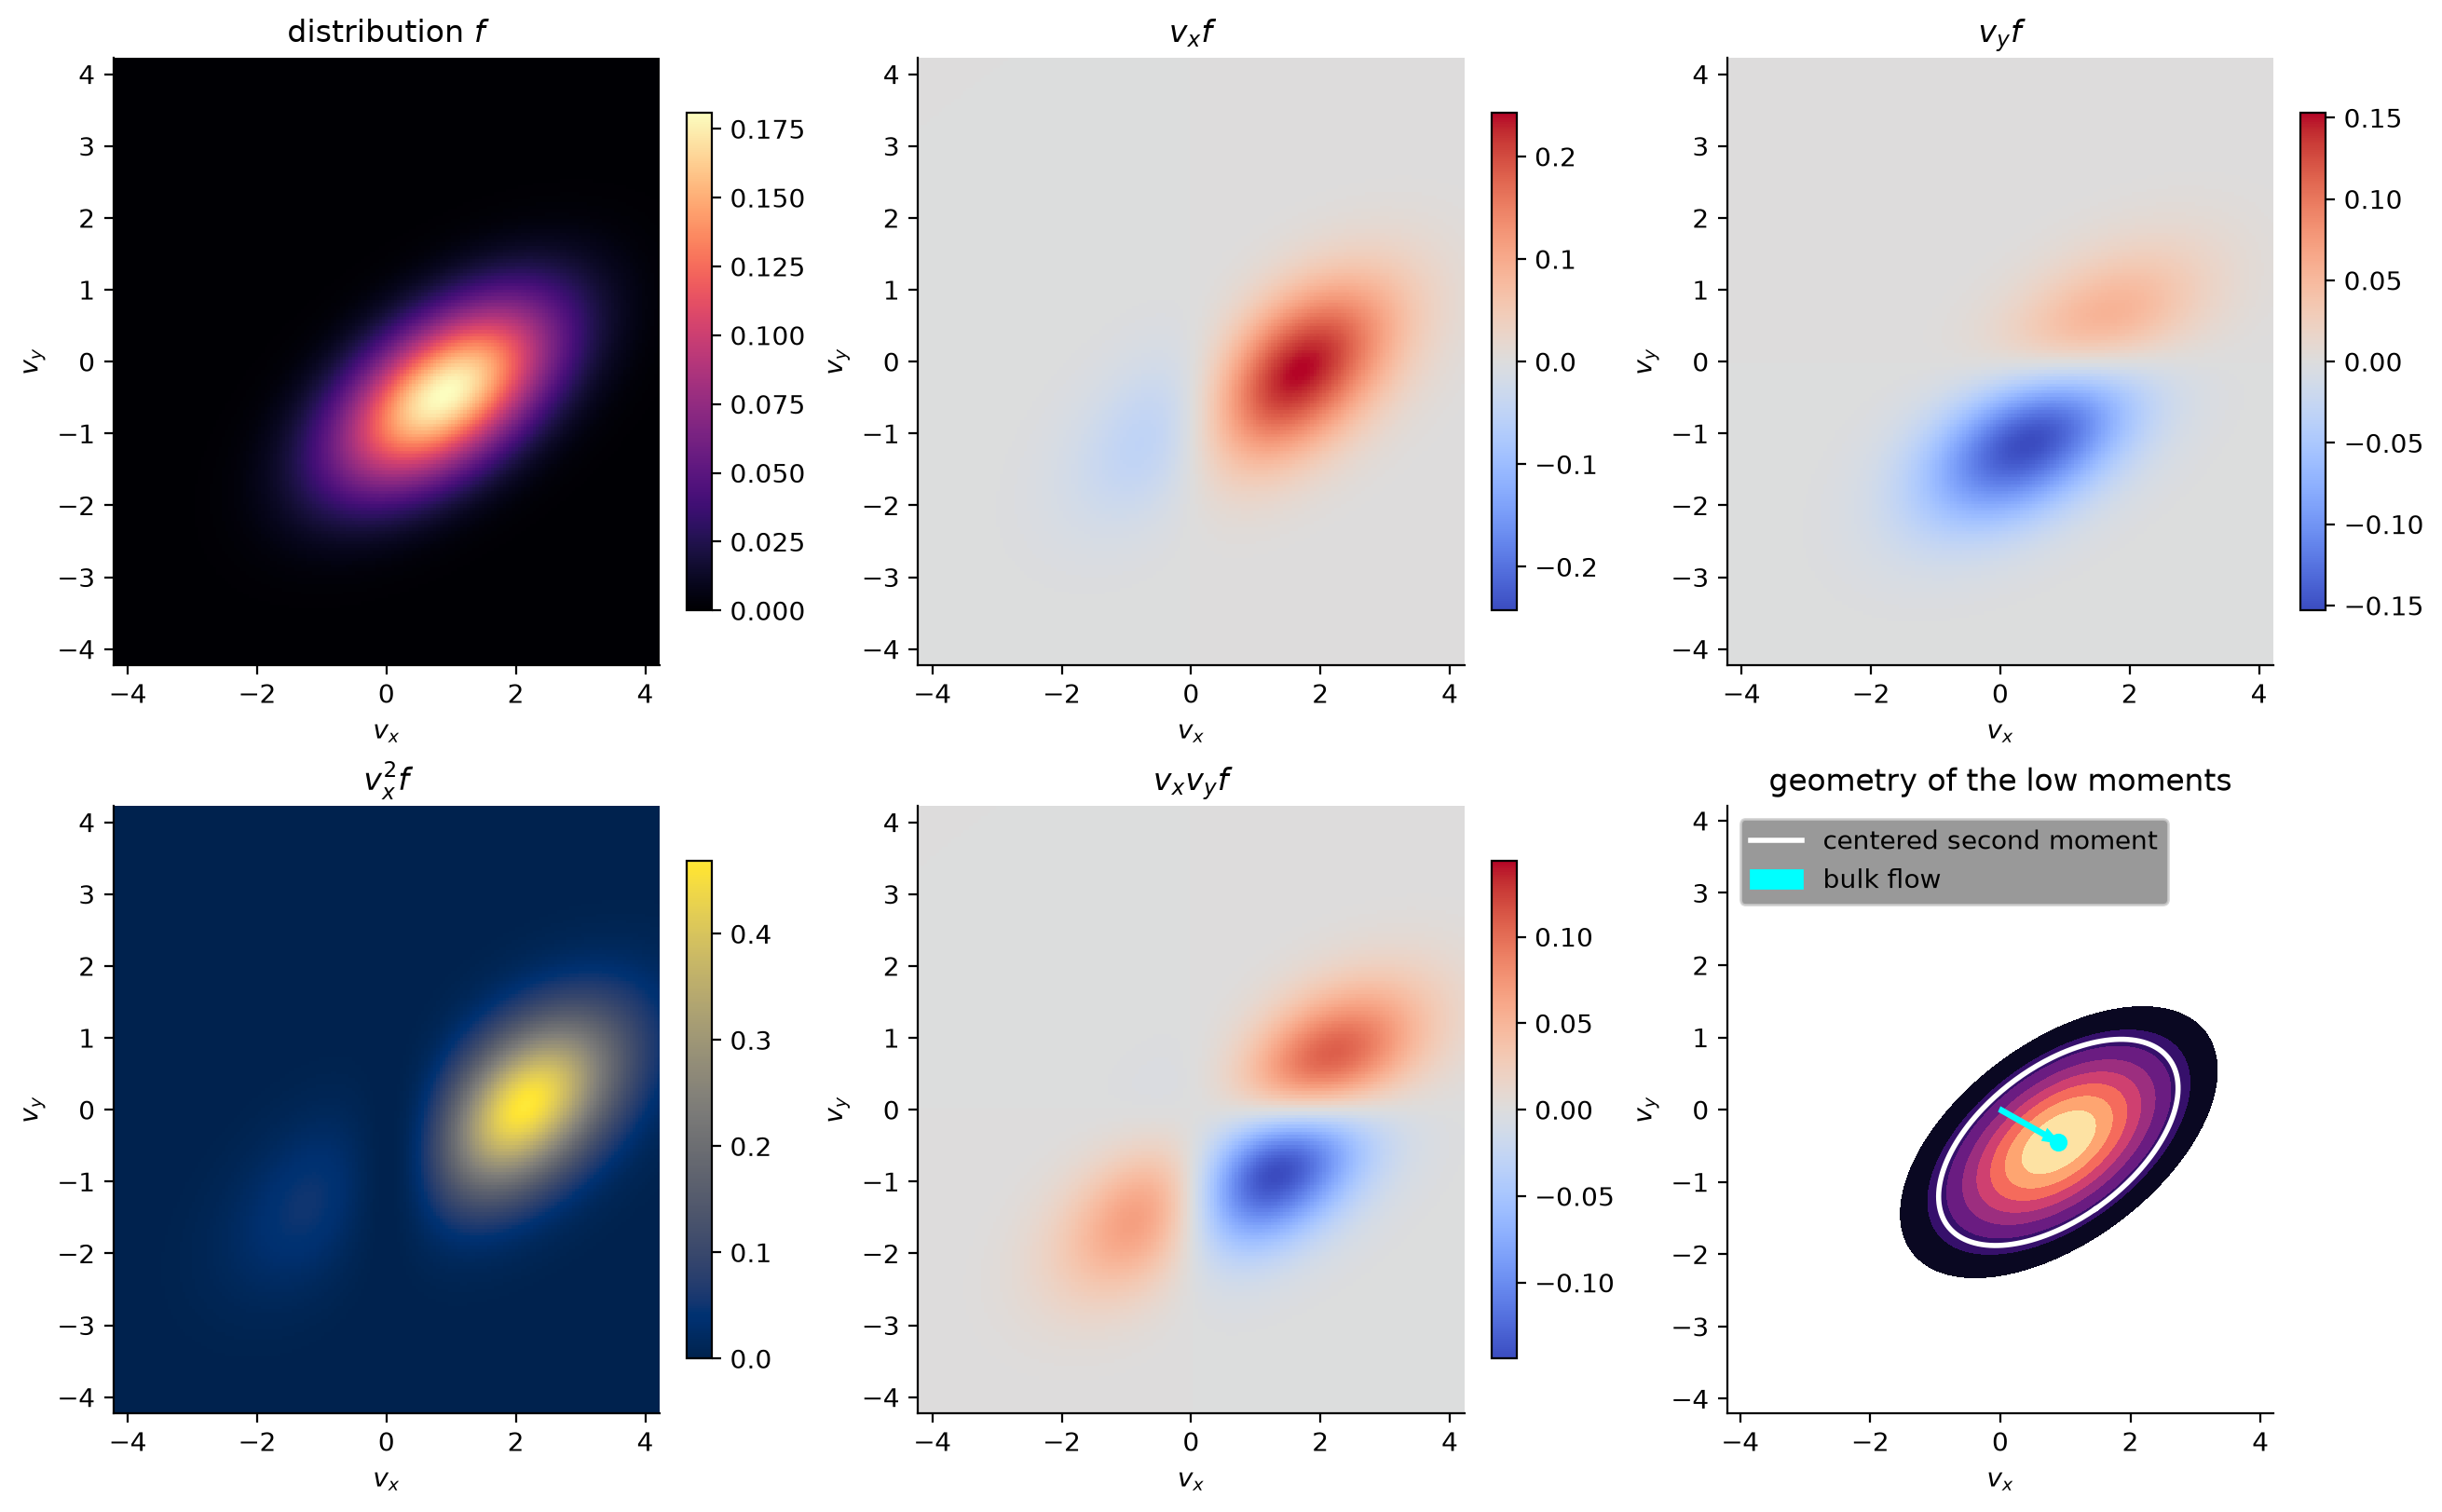

M^(0) = 1.000000
M^(1) = [ 0.892293 -0.453105]
M^(2) =
[[2.120083 0.134972]
 [0.134972 1.000802]]
centered second moment =
[[1.323896 0.539275]
 [0.539275 0.795498]]


In [2]:
vx_line = np.linspace(-4.2, 4.2, 181)
vy_line = np.linspace(-4.2, 4.2, 181)
vx, vy = np.meshgrid(vx_line, vy_line)

mean = np.array([0.9, -0.45])
cov = np.array([
    [1.35, 0.55],
    [0.55, 0.8],
])

f = gaussian_2d(vx, vy, mean, cov)
f = f / raw_moments_2d(f, vx, vy)['m0']
moments = raw_moments_2d(f, vx, vy)
bulk = moments['m1'] / moments['m0']
pressure_like = centered_tensor_2d(moments)
ellipse = ellipse_points(pressure_like, bulk)

fields = [
    ('distribution $f$', f, 'magma', False),
    ('$v_x f$', vx * f, 'coolwarm', True),
    ('$v_y f$', vy * f, 'coolwarm', True),
    ('$v_x^2 f$', vx**2 * f, 'cividis', False),
    ('$v_x v_y f$', vx * vy * f, 'coolwarm', True),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
for ax, (title, field, cmap, signed) in zip(axes.flat[:5], fields):
    if signed:
        vmax = np.max(np.abs(field))
        mesh = ax.pcolormesh(vx, vy, field, shading='auto', cmap=cmap, vmin=-vmax, vmax=vmax)
    else:
        mesh = ax.pcolormesh(vx, vy, field, shading='auto', cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel('$v_x$')
    ax.set_ylabel('$v_y$')
    fig.colorbar(mesh, ax=ax, shrink=0.82)

ax = axes.flat[5]
levels = np.linspace(f.min(), f.max(), 10)[1:]
ax.contourf(vx, vy, f, levels=levels, cmap='magma')
ax.plot(ellipse[0], ellipse[1], color='white', lw=2, label='centered second moment')
ax.arrow(0, 0, bulk[0], bulk[1], width=0.05, color='cyan', length_includes_head=True, label='bulk flow')
ax.scatter([bulk[0]], [bulk[1]], color='cyan', s=35)
ax.set_title('geometry of the low moments')
ax.set_xlabel('$v_x$')
ax.set_ylabel('$v_y$')
ax.legend(loc='upper left', facecolor='gray')

plt.show()

print(f"M^(0) = {moments['m0']:.6f}")
print('M^(1) =', np.round(moments['m1'], 6))
print('M^(2) =')
print(np.round(moments['m2'], 6))
print('centered second moment =')
print(np.round(pressure_like, 6))


## 2. rotations act once per index

If a moment carries one index, it transforms like a vector. If it carries two indices, it transforms like a rank-2 tensor:

$$
M_i' = R_{ij} M_j,
\qquad
M_{ij}' = R_{ia} R_{jb} M_{ab}.
$$

The next cell rotates the same velocity-space distribution and compares the measured moments to the tensor-transformation prediction.


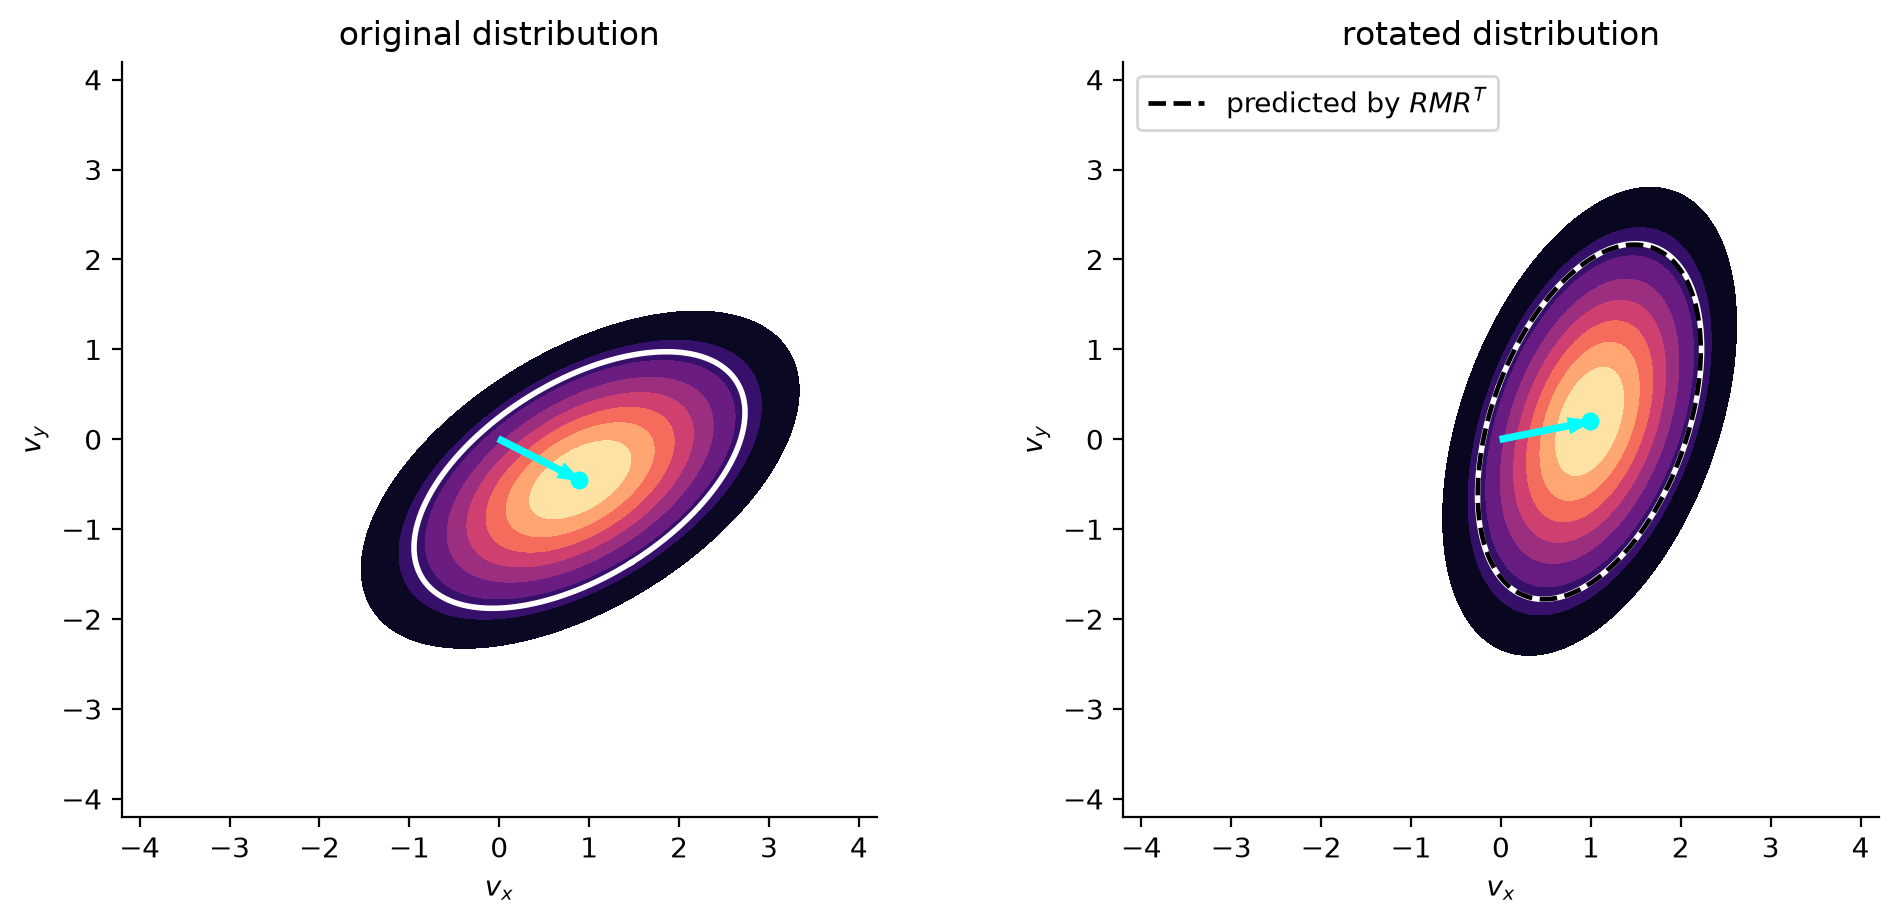

||M^(1)_rot - R M^(1)|| = 0.006548429013639113
||M^(2)_rot - R M^(2) R^T|| = 0.027755355298168895
||centered_rot - R centered R^T|| = 0.016962515821393784


In [3]:
theta = np.deg2rad(38)
r = rotation_matrix(theta)

mean_rot = r @ mean
cov_rot = r @ cov @ r.T

f_rot = gaussian_2d(vx, vy, mean_rot, cov_rot)
f_rot = f_rot / raw_moments_2d(f_rot, vx, vy)['m0']
moments_rot = raw_moments_2d(f_rot, vx, vy)
bulk_rot = moments_rot['m1'] / moments_rot['m0']
pressure_like_rot = centered_tensor_2d(moments_rot)

pred_m1_rot = r @ moments['m1']
pred_m2_rot = r @ moments['m2'] @ r.T
pred_centered_rot = r @ pressure_like @ r.T
pred_ellipse = ellipse_points(pred_centered_rot, pred_m1_rot / moments['m0'])
rot_ellipse = ellipse_points(pressure_like_rot, bulk_rot)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
for ax, dist, center, ellipse_now, title in [
    (axes[0], f, bulk, ellipse, 'original distribution'),
    (axes[1], f_rot, bulk_rot, rot_ellipse, 'rotated distribution'),
]:
    levels = np.linspace(dist.min(), dist.max(), 10)[1:]
    ax.contourf(vx, vy, dist, levels=levels, cmap='magma')
    ax.plot(ellipse_now[0], ellipse_now[1], color='white', lw=2)
    ax.arrow(0, 0, center[0], center[1], width=0.05, color='cyan', length_includes_head=True)
    ax.scatter([center[0]], [center[1]], color='cyan', s=30)
    ax.set_aspect('equal')
    ax.set_xlabel('$v_x$')
    ax.set_ylabel('$v_y$')
    ax.set_title(title)

axes[1].plot(pred_ellipse[0], pred_ellipse[1], '--', color='black', lw=1.7, label='predicted by $R M R^T$')
axes[1].legend(loc='upper left')
plt.show()

print('||M^(1)_rot - R M^(1)|| =', np.linalg.norm(moments_rot['m1'] - pred_m1_rot))
print('||M^(2)_rot - R M^(2) R^T|| =', np.linalg.norm(moments_rot['m2'] - pred_m2_rot))
print('||centered_rot - R centered R^T|| =', np.linalg.norm(pressure_like_rot - pred_centered_rot))


## 3. isotropic plus traceless pieces of the pressure tensor

For a rank-2 symmetric tensor in 3d, the natural split is

$$
P_{ij} = p\,\delta_{ij} + \Pi_{ij},
\qquad
p = \frac{1}{3} P_{kk},
\qquad
\Pi_{ii} = 0.
$$

A bi-Maxwellian aligned with a magnetic-field direction $\hat{\mathbf{b}}$ gives the standard form

$$
P_{ij} = p_\perp \delta_{ij} + (p_\parallel - p_\perp) b_i b_j.
$$

The sphere below is the isotropic part. The stretched ellipsoid is the full pressure tensor.


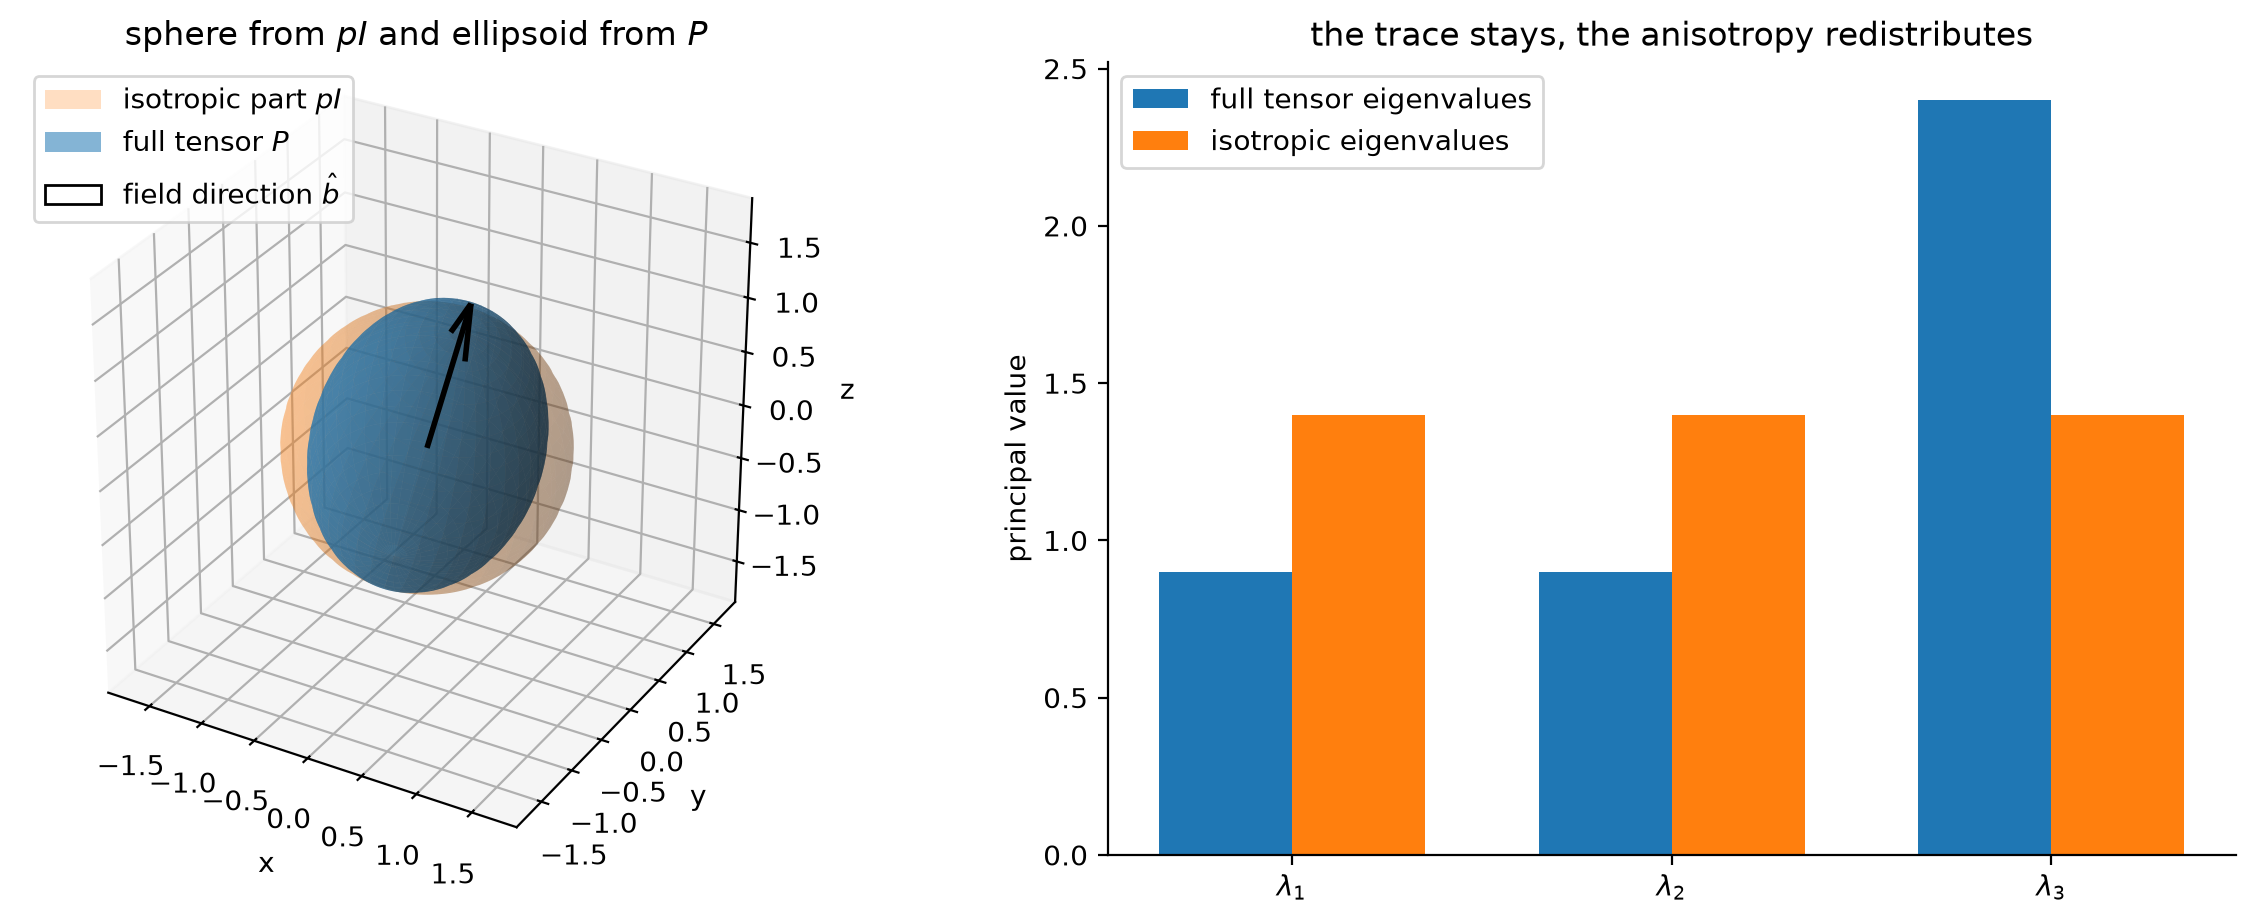

p = 1.400
trace(Pi) = -4.44e-16
||Pi|| = 1.225


In [4]:
b = np.array([0.35, -0.25, 0.9])
b = b / np.linalg.norm(b)
p_parallel = 2.4
p_perp = 0.9

p_tensor = pressure_tensor(b, p_parallel, p_perp)
p_iso = np.trace(p_tensor) / 3 * np.eye(3)
pi_tensor = p_tensor - p_iso

x_full, y_full, z_full = ellipsoid_from_tensor(p_tensor)
x_iso, y_iso, z_iso = ellipsoid_from_tensor(p_iso)
full_evals = np.linalg.eigvalsh(p_tensor)
iso_evals = np.linalg.eigvalsh(p_iso)

fig = plt.figure(figsize=(12, 4.5), constrained_layout=True)
ax0 = fig.add_subplot(1, 2, 1, projection='3d')
ax1 = fig.add_subplot(1, 2, 2)

ax0.plot_surface(x_iso, y_iso, z_iso, color='tab:orange', alpha=0.25, linewidth=0)
ax0.plot_surface(x_full, y_full, z_full, color='tab:blue', alpha=0.55, linewidth=0)
ax0.quiver(0, 0, 0, b[0], b[1], b[2], color='black', linewidth=2, length=1.9)
ax0.set_title('sphere from $p I$ and ellipsoid from $P$')
ax0.set_xlabel('x')
ax0.set_ylabel('y')
ax0.set_zlabel('z')
ax0.set_box_aspect([1, 1, 1])
limit = 1.9
ax0.set_xlim(-limit, limit)
ax0.set_ylim(-limit, limit)
ax0.set_zlim(-limit, limit)
ax0.legend(handles=[
    Patch(facecolor='tab:orange', alpha=0.25, label='isotropic part $p I$'),
    Patch(facecolor='tab:blue', alpha=0.55, label='full tensor $P$'),
    Patch(facecolor='white', edgecolor='black', label=r'field direction $\hat{b}$'),
], loc='upper left')

xpos = np.arange(3)
width = 0.35
ax1.bar(xpos - width / 2, np.sort(full_evals), width=width, color='tab:blue', label='full tensor eigenvalues')
ax1.bar(xpos + width / 2, np.sort(iso_evals), width=width, color='tab:orange', label='isotropic eigenvalues')
ax1.set_xticks(xpos, [r'$\lambda_1$', r'$\lambda_2$', r'$\lambda_3$'])
ax1.set_ylabel('principal value')
ax1.set_title('the trace stays, the anisotropy redistributes')
ax1.legend(loc='upper left')
summary = '\n'.join([
    f'p = {np.trace(p_tensor) / 3:.3f}',
    f'trace(Pi) = {np.trace(pi_tensor):.2e}',
    f'||Pi|| = {np.linalg.norm(pi_tensor):.3f}',
])

plt.show()
print(summary)


## 4. from symmetric tensors to angular multipoles

The symmetric rank-$k$ tensor space is not a single irreducible representation. Instead,

$$
\mathrm{Sym}^k(V) = \ell = k \oplus \ell = k - 2 \oplus \ell = k - 4 \oplus \cdots
$$

The left plot marks which $\ell$ values appear for the first few moment orders. The right plot shows the axisymmetric basis functions $P_\ell(\mu)$ that survive in a gyrotropic distribution.


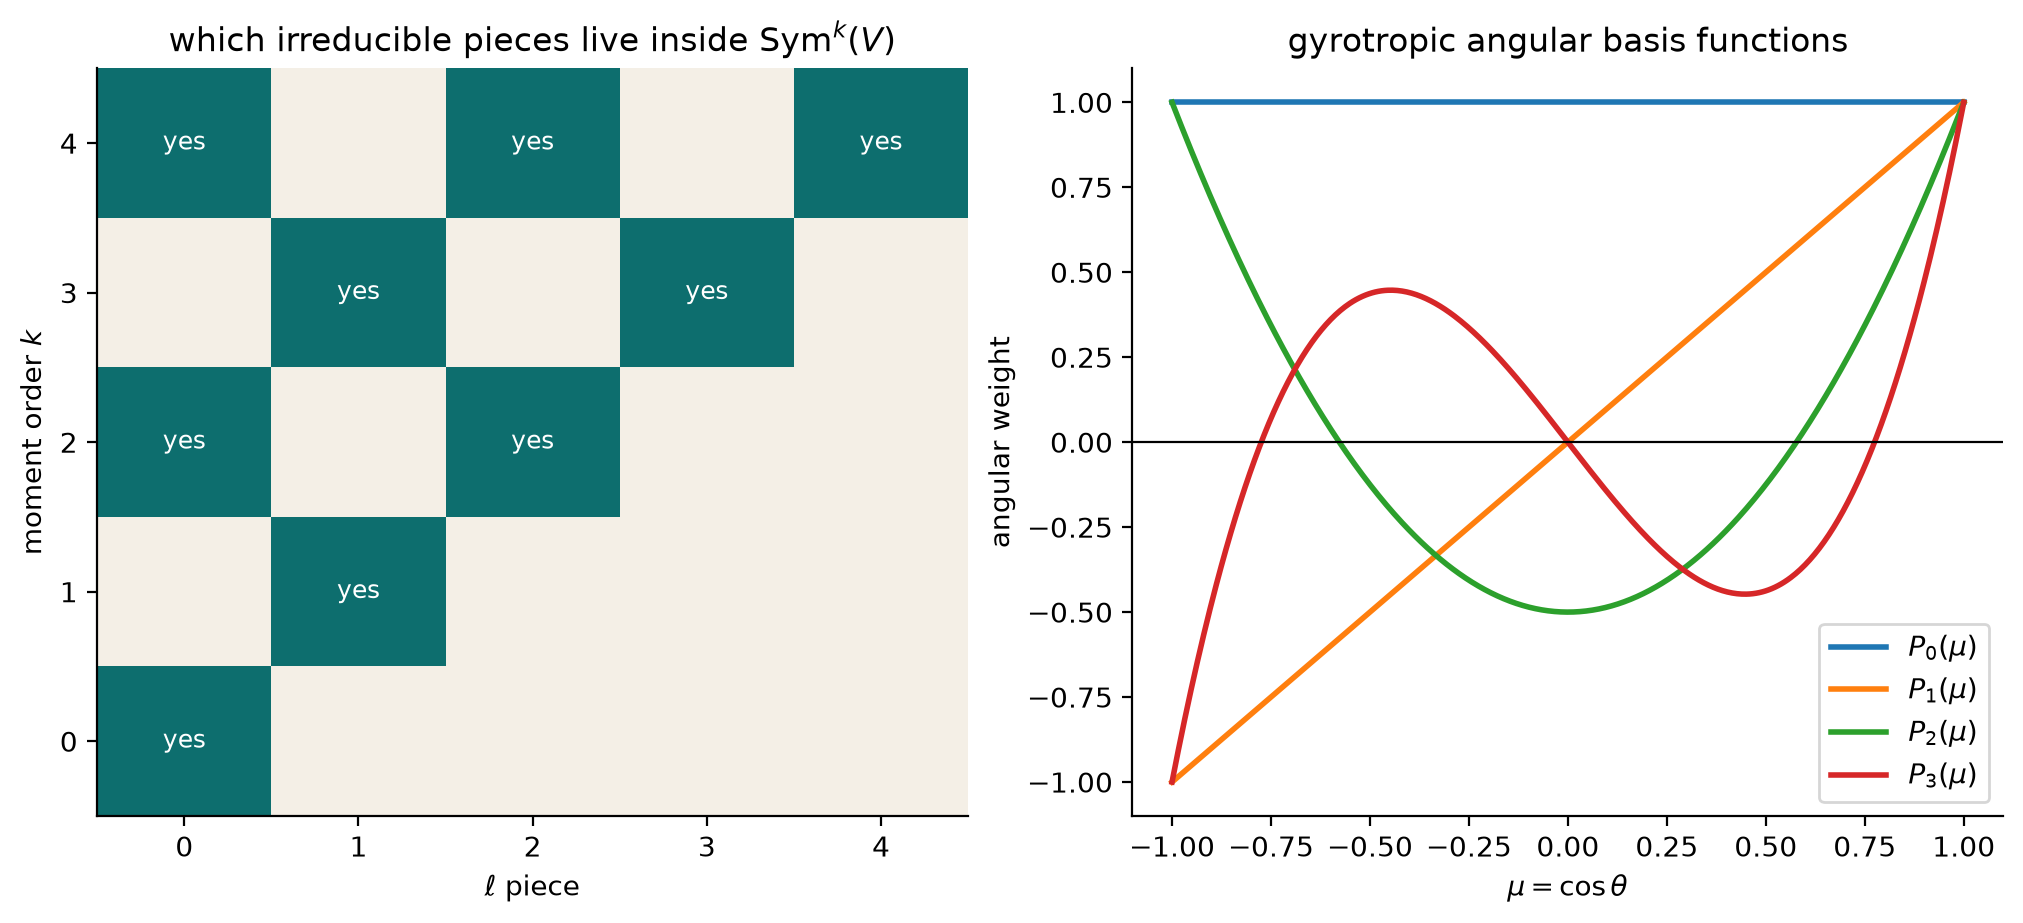

In [5]:
k_max = 4
decomp = np.zeros((k_max + 1, k_max + 1), dtype=int)
for k in range(k_max + 1):
    for ell in range(k, -1, -2):
        decomp[k, ell] = 1

mu = np.linspace(-1, 1, 500)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

cmap = ListedColormap(['#f4efe6', '#0d6e6e'])
axes[0].imshow(decomp, origin='lower', cmap=cmap, aspect='auto', vmin=0, vmax=1)
for k in range(k_max + 1):
    for ell in range(k_max + 1):
        label = 'yes' if decomp[k, ell] else ''
        axes[0].text(ell, k, label, ha='center', va='center', color='white' if label else '#555555', fontsize=9)
axes[0].set_xlabel(r'$\ell$ piece')
axes[0].set_ylabel('moment order $k$')
axes[0].set_xticks(range(k_max + 1))
axes[0].set_yticks(range(k_max + 1))
axes[0].set_title(r'which irreducible pieces live inside $\mathrm{Sym}^k(V)$')

for ell in range(4):
    axes[1].plot(mu, legendre_mode(ell, mu), lw=2, label=rf'$P_{{{ell}}}(\mu)$')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel(r'$\mu = \cos \theta$')
axes[1].set_ylabel('angular weight')
axes[1].set_title('gyrotropic angular basis functions')
axes[1].legend(loc='lower right')

plt.show()


## 5. gyrotropic versus nongyrotropic angular structure

If the magnetic field defines the polar axis, a gyrotropic distribution depends only on $\mu = \cos	\theta$, so it has no $\phi$ dependence. In spherical-harmonic language that means only $m = 0$ modes are present.

Adding a term with explicit azimuthal variation creates nongyrotropy and therefore introduces $m \ne 0$ structure.


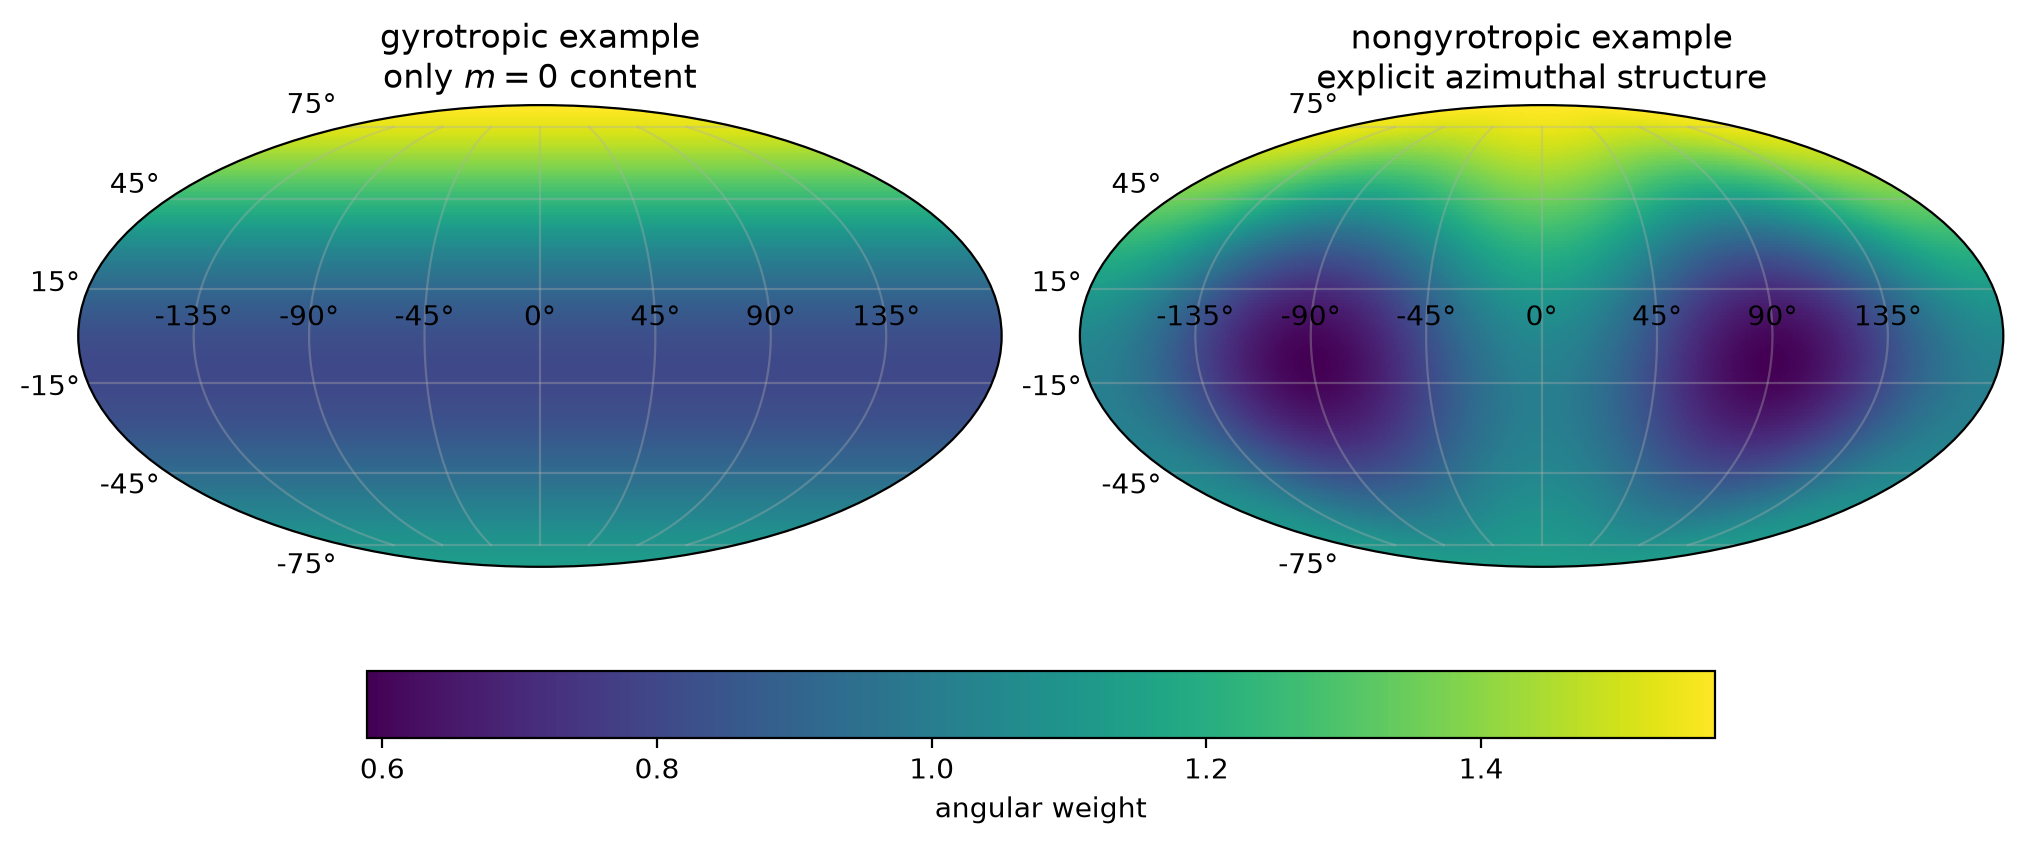

max azimuthal variation in gyrotropic map = 4.440892098500626e-16
max azimuthal variation in nongyrotropic map = 0.15577761270618196


In [10]:
theta_line = np.linspace(1e-3, np.pi - 1e-3, 181)
phi_line = np.linspace(-np.pi, np.pi, 361)
phi_grid, theta_grid = np.meshgrid(phi_line, theta_line)
mu_grid = np.cos(theta_grid)
lat_grid = 0.5 * np.pi - theta_grid

gyro = 1.0 + 0.22 * legendre_mode(1, mu_grid) + 0.35 * legendre_mode(2, mu_grid)
nongyro = gyro + 0.22 * np.sin(theta_grid)**2 * np.cos(2 * phi_grid)

fig = plt.figure(figsize=(10, 4.5), constrained_layout=True)
ax0 = fig.add_subplot(1, 2, 1, projection='mollweide')
ax1 = fig.add_subplot(1, 2, 2, projection='mollweide')

vmin = min(float(gyro.min()), float(nongyro.min()))
vmax = max(float(gyro.max()), float(nongyro.max()))
lon_ticks_deg = np.arange(-135, 136, 45)
lat_ticks_deg = np.arange(-75, 76, 30)
lon_ticks = np.deg2rad(lon_ticks_deg)
lat_ticks = np.deg2rad(lat_ticks_deg)
lon_labels = [f'{deg}\N{DEGREE SIGN}' for deg in lon_ticks_deg]
lat_labels = [f'{deg}\N{DEGREE SIGN}' for deg in lat_ticks_deg]

for ax, field, title in [
    (ax0, gyro, 'gyrotropic example\nonly $m = 0$ content'),
    (ax1, nongyro, 'nongyrotropic example\nexplicit azimuthal structure'),
]:
    mesh = ax.pcolormesh(phi_grid, lat_grid, field, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    ax.grid(True, alpha=0.35)
    ax.set_xticks(lon_ticks)
    ax.set_xticklabels(lon_labels)
    ax.set_yticks(lat_ticks)
    ax.set_yticklabels(lat_labels)
    ax.set_title(title)

fig.colorbar(mesh, ax=[ax0, ax1], orientation='horizontal', pad=0.12, shrink=0.7, label='angular weight')
plt.show()

print('max azimuthal variation in gyrotropic map =', np.max(np.std(gyro, axis=1)))
print('max azimuthal variation in nongyrotropic map =', np.max(np.std(nongyro, axis=1)))


## thoughts

- moment integrands are just the same distribution multiplied by progressively higher powers of velocity
- rotations act once on each tensor index, which is why the $k$-th moment gets $k$ copies of the rotation matrix
- the pressure tensor naturally splits into an isotropic scalar part and a traceless anisotropic part
- gyrotropic structure is axisymmetric and therefore uses only $m = 0$ angular modes
- nongyrotropy shows up as explicit azimuthal structure, which is the angular signature of $m \ne 0$
